# Set-up

In [1]:
import os
import glob
import numpy as np
import pandas as pd

import logomaker as lm

from tangermeme.io import read_meme

from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Set scanpy and matplotlib styles for publication
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
from matplotlib.patheffects import AbstractPathEffect
from matplotlib.textpath import TextPath
from matplotlib.transforms import Affine2D
from matplotlib.font_manager import FontProperties


class LogoGlyph(AbstractPathEffect):
    def __init__(self, glyph, ref_glyph='E', font_props=None,
                 offset=(0., 0.), **kwargs):

        super().__init__(offset)

        path_orig = TextPath((0, 0), glyph, size=1, prop=font_props)
        dims = path_orig.get_extents()
        ref_dims = TextPath((0, 0), ref_glyph, size=1, prop=font_props).get_extents()

        h_scale = 1 / dims.height
        ref_width = max(dims.width, ref_dims.width)
        w_scale = 1 / ref_width
        w_shift = (1 - dims.width / ref_width) / 2
        x_shift = -dims.x0
        y_shift = -dims.y0
        stretch = (
            Affine2D()
            .translate(tx=x_shift, ty=y_shift)
            .scale(sx=w_scale, sy=h_scale)
            .translate(tx=w_shift, ty=0)
        )

        self.path = stretch.transform_path(path_orig)

        #: The dictionary of keywords to update the graphics collection with.
        self._gc = kwargs

    def draw_path(self, renderer, gc, tpath, affine, rgbFace):
        return renderer.draw_path(gc, self.path, affine, rgbFace)


def plot_logo(ax, heights, glyphs, colors=None, font_props=None, shade_bounds=None):
    if colors is None:
        colors = {g: None for g in glyphs}

    ax.margins(x=0, y=0)
    
    pos_values = np.clip(heights, 0, None)
    neg_values = np.clip(heights, None, 0)
    pos_order = np.argsort(pos_values, axis=0)
    neg_order = np.argsort(neg_values, axis=0)[::-1,:]
    pos_reorder = np.argsort(pos_order, axis=0)
    neg_reorder = np.argsort(neg_order, axis=0)
    pos_offsets = np.take_along_axis(
        np.cumsum(
            np.take_along_axis(pos_values, pos_order, axis=0), axis=0
        ), pos_reorder, axis=0
    )
    neg_offsets = np.take_along_axis(
        np.cumsum(
            np.take_along_axis(neg_values, neg_order, axis=0), axis=0
        ), neg_reorder, axis=0
    )
    bottoms = pos_offsets + neg_offsets - heights

    x = np.arange(heights.shape[1])

    for glyph, height, bottom in zip(glyphs, heights, bottoms):
        ax.bar(x, height, 0.95, bottom=bottom, 
               path_effects=[LogoGlyph(glyph, font_props=font_props)], color=colors[glyph])

    if shade_bounds is not None:
        start, end = shade_bounds
        ax.axvspan(start - 0.5, end - 0.5, color='0.9', zorder=-1)

    ax.axhline(zorder=-1, linewidth=0.5, color='black')


LOGO_ALPHABET = 'ACGT'
LOGO_COLORS = {"A": '#109648', "C": '#255C99', "G": '#F7B32B', "T": '#D62839'}
LOGO_FONT = FontProperties(weight="bold")

In [3]:
path_motif_file = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/3_single_task_models/motifs/gimme_cluster/meme/combined.meme"
path_motif_annotation = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/3_single_task_models/motifs/gimme_cluster/tfs_initial.txt"

path_out = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/3_single_task_models/motifs/gimme_cluster/summary"
os.makedirs(path_out, exist_ok=True)

# Load motifs

In [4]:
# Load motifs
motif_dict = read_meme(path_motif_file)
motifs = list(motif_dict.items())
names = np.array([m[0] for m in motifs], dtype="U")

In [5]:
# Load motif annotations
initial_motifs = pd.read_csv(path_motif_annotation, sep="\t", header=None)
initial_motifs.columns = ["cluster_name", "top_tomtom_annotation", "evalue"]
annotation_dict = initial_motifs.set_index("cluster_name")["top_tomtom_annotation"].to_dict()
df = initial_motifs

# Plot

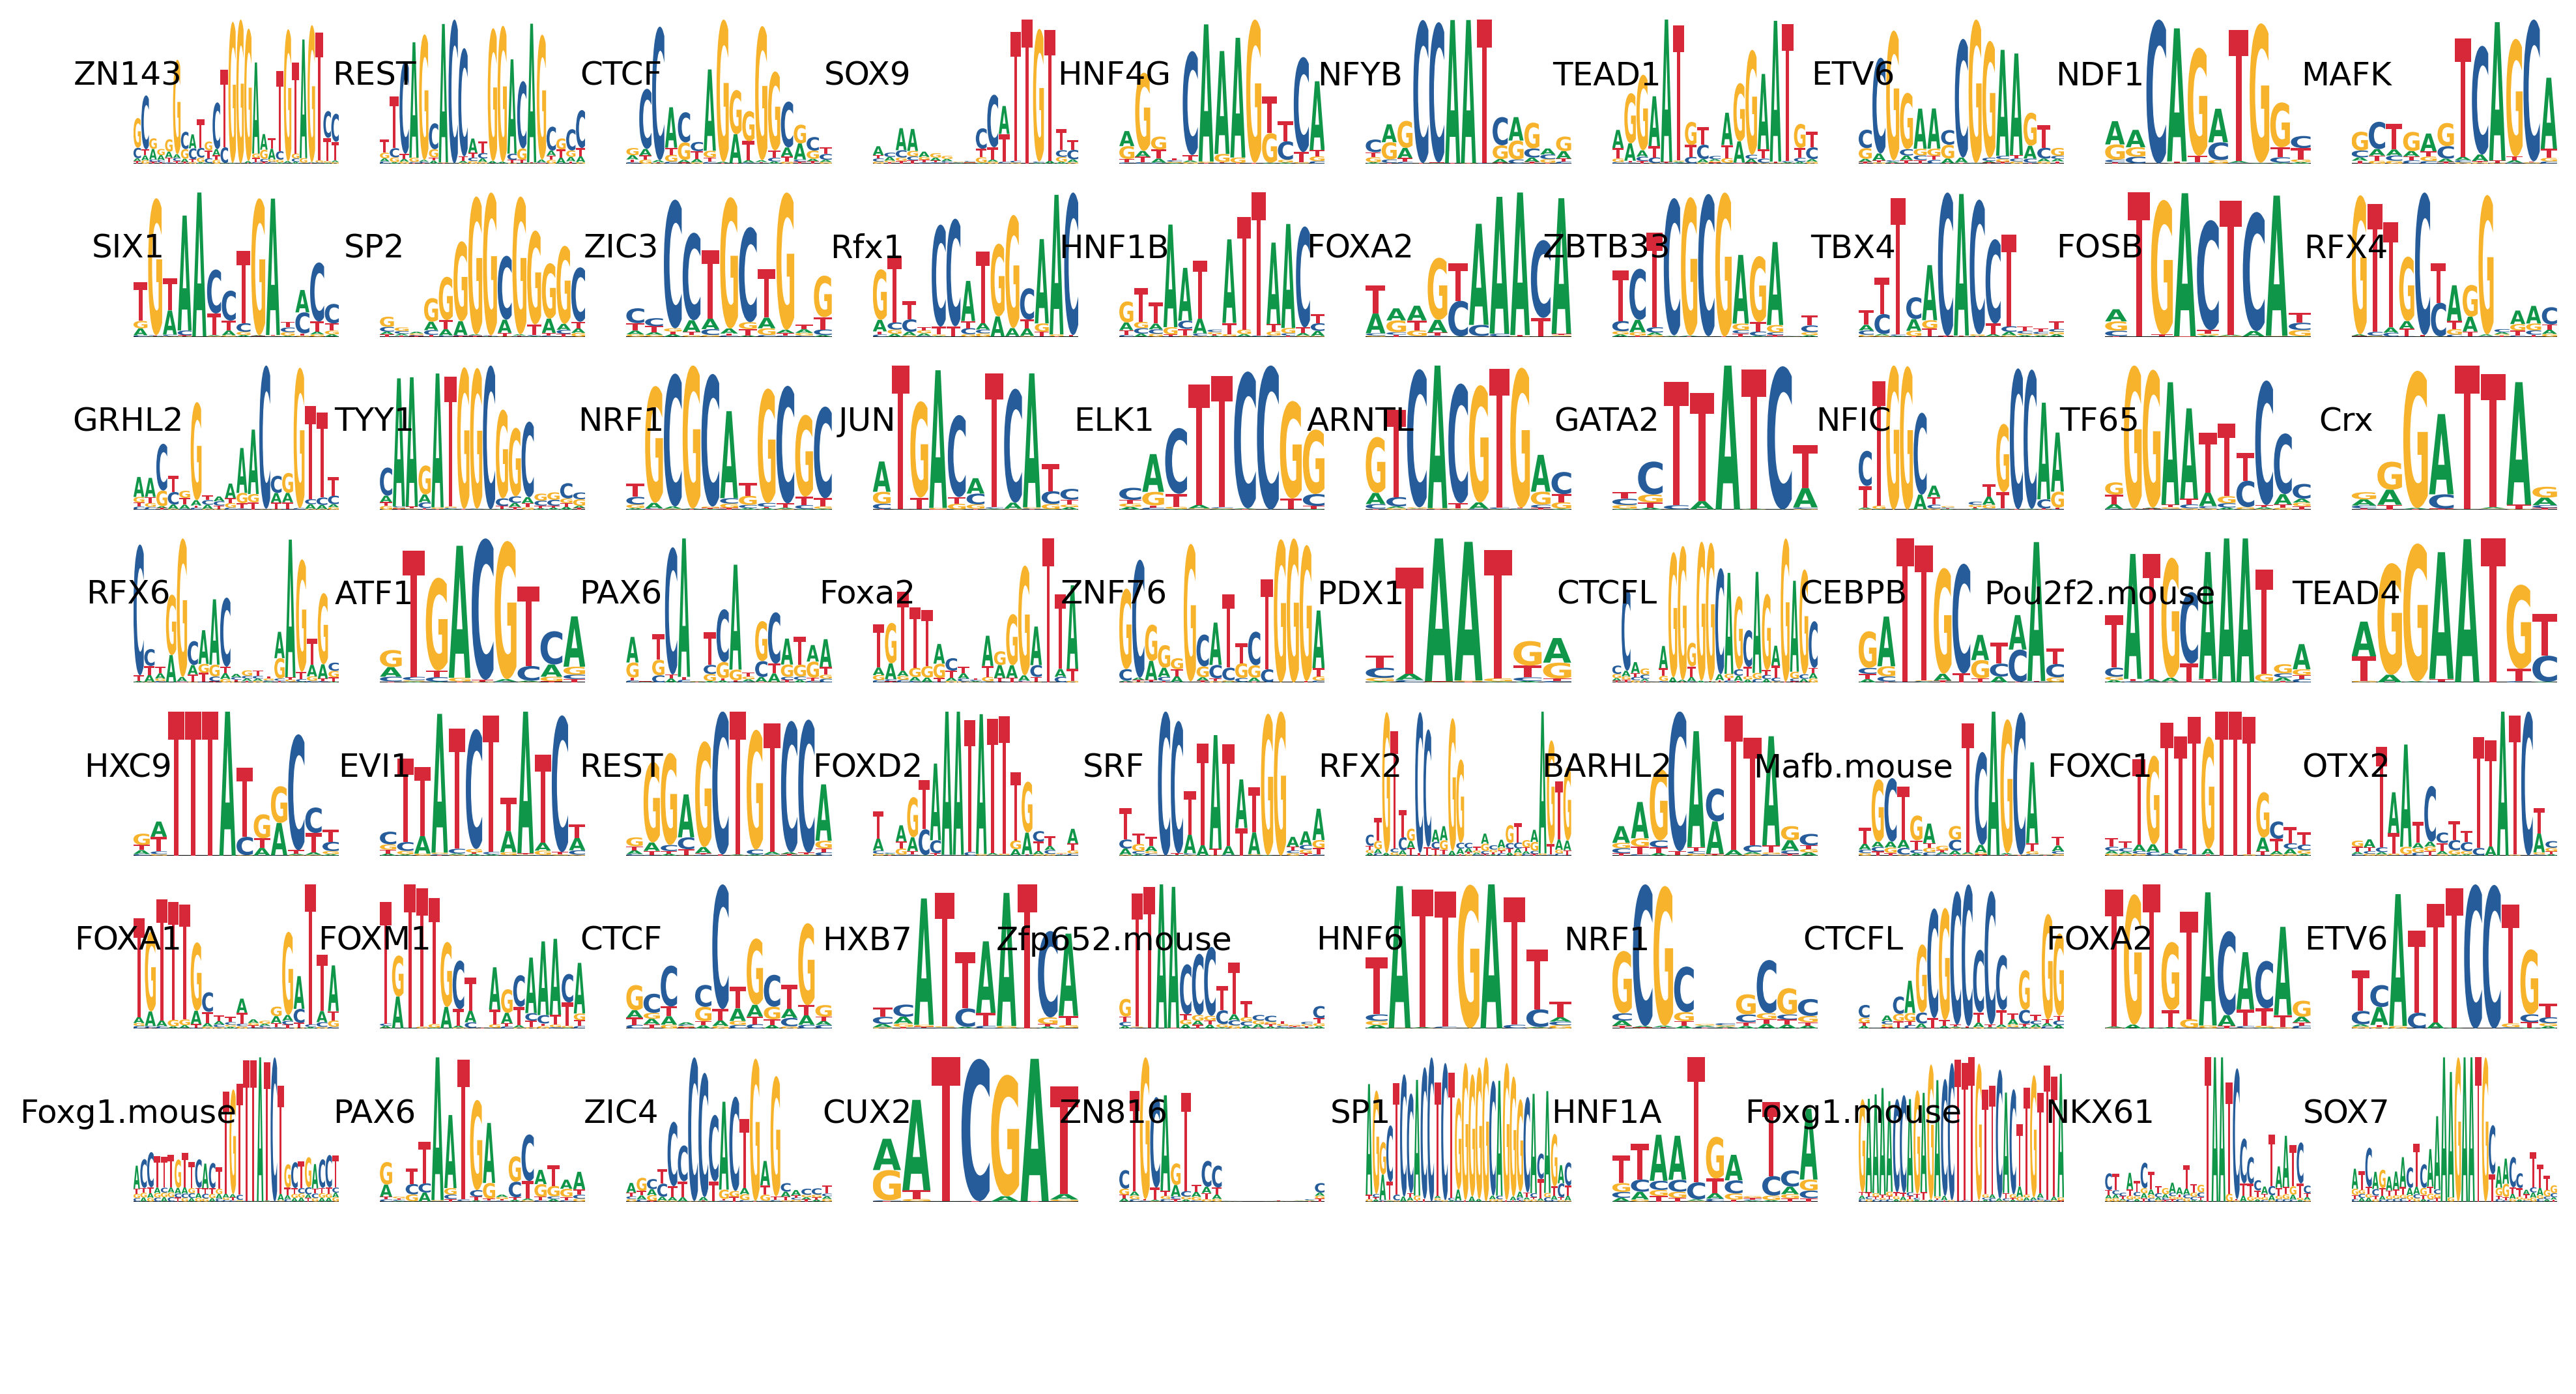

In [6]:
# Set the number of motifs
n_motifs = len(df)
n_cols = 10
n_rows = (n_motifs // n_cols) + 1

# Create a subplot grid for the logos (one column and n_motifs rows)
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16, 9), dpi=300)
axes = axes.flatten()

# Loop
for i in range(n_motifs):

    # Get the motif name
    sig_motif = df["cluster_name"].iloc[i]

    # Plot the logo in each row
    ppm = motif_dict[sig_motif].numpy().T
    lm_df = lm.transform_matrix(
        df=pd.DataFrame(ppm, columns=list(LOGO_ALPHABET)),
        from_type='probability',
        to_type='information',
    )
    ax_logo = axes[i]

    # Plot logo with logomaker
    lm.Logo(
        lm_df,
        ax=ax_logo,
        color_scheme=LOGO_COLORS,
        fade_below=0.1,
        font_name=LOGO_FONT.get_name(),
    )
    
    # Hide spines
    for name, spine in ax_logo.spines.items():
        spine.set_visible(False)
    
    # Remove ticks
    ax_logo.set_xticks([])
    ax_logo.set_yticks([])

    # Set label for each motif as annotation
    annotation = annotation_dict.get(sig_motif, "Unknown").split("_")[0]
    ax_logo.set_ylabel(annotation, fontsize=12, rotation=0, labelpad=2)

# remove unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
    
plt.savefig(f"{path_out}/sc-islet-differentiation_10X-Multiome_motif_logos.pdf", dpi=300)
plt.show()

# DONE!

---